<a href="https://colab.research.google.com/github/abrahamdevargas14-byte/Data-Science-Cohort-20/blob/main/Project_2/Project_2_Housing_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Project 2: Linear Regression Housing Price Prediction
Deep Dive Data Science Cohort-20

Abraham De Vargas, 04/12/2026

## Setup
All imports and file paths are defined here at the top of the notebook.

In [ ]:
# ============================================================
# IMPORTS
# Standard data science libraries for manipulation, math,
# visualization, and machine learning.
# ============================================================

import requests
import matplotlib.pyplot as plt   # plotting
import numpy as np                # numerical operations
import pandas as pd               # data manipulation
import seaborn as sns            # statistical visualizations

# Linear models: plain OLS, Ridge (L2), and Lasso (L1) regularization
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Splits data into train/test sets
from sklearn.model_selection import train_test_split

# Scales features to zero mean and unit variance -- required for Ridge/Lasso
from sklearn.preprocessing import StandardScaler

# Secondary metric used alongside RMSPE
from sklearn.metrics import mean_squared_error

# ============================================================
# FILE PATHS
# Storing paths as variables makes them easy to update in
# one place if the data source changes.
# ============================================================
base_path = 'https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/'
data_path = base_path + 'Housing.Data.csv'

## 1. Problem Definition
Real estate pricing is data-driven. Buyers, sellers, and lenders all want accurate estimates of what a home is worth — and small errors in those estimates can mean thousands of dollars.

This project uses the Ames, Iowa housing dataset to answer this question: Given a set of features about a house, what will its sale price be?

Since we're predicting a continuous numeric value (sale price), this is a supervised regression problem. The `SalePrice` column is the target. I'll use Linear Regression with feature scaling and regularization (Ridge and Lasso) as covered in class. The goal is to minimize RMSPE — Root Mean Squared Percentage Error — which penalizes errors proportionally rather than in raw dollar terms, making it fair across cheap and expensive homes alike.

The dataset contains ~80 features describing nearly every aspect of a home: size, quality, age, neighborhood, garage, basement, and more.

| Question | Answer |
|---|---|
| What is the business problem? | Predict the sale price of a residential home |
| Supervised or unsupervised? | Supervised |
| What is the target? | SalePrice — continuous numeric value |
| Statistical data type of target? | Numeric (continuous) |
| Classification or regression? | Regression |
| Performance metric? | RMSPE — Root Mean Squared Percentage Error |

## 2. Data Collection/Sources
The data is the Ames Housing Dataset, originally compiled by Professor Dean De Cock. It contains residential property sales in Ames, Iowa.

The dataset is hosted on AWS S3 and provided by Deep Dive Coding. It contains roughly 2,637 rows and 81 columns spanning numeric, ordinal, and nominal features. The target column is `SalePrice`. It can be loaded directly from the URL using `pd.read_csv()`.

Some columns contain nulls that require thoughtful handling — for example, a null in `Garage Type` likely means the home has no garage, not that the data is missing. This distinction will matter in cleaning.

In [ ]:
# ============================================================
# LOAD DATA
# Read the CSV directly from the S3 URL into a DataFrame.
# No local download needed -- pandas handles the HTTP request.
# ============================================================
df = pd.read_csv(data_path)
df

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,903231070,50,RM,52.0,6240,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,Shed,400,9,2006,WD,Normal,114500
2633,906201021,80,RL,74.0,10778,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,7,2009,WD,Normal,162000
2634,533253070,120,RL,61.0,3782,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2009,WD,Normal,211500
2635,527376100,20,RL,78.0,10140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,8,2009,WD,Normal,165000


## 3. Data Cleaning
Before modeling, the data needs to be examined for structure and quality. This includes checking for nulls, duplicates, unique identifiers, and non-numeric columns that will need to be encoded or dropped.

Key decisions:
- Columns with a very high null rate (>80%) will be dropped entirely — they carry too little information
- For many null values in categorical columns (e.g., Garage Type, Pool QC), the null itself means 'none' — these will be filled with `'None'`
- Numeric nulls will be imputed with the column median, which is robust to outliers
- Columns that are IDs or carry no predictive value (like PID) will be dropped
- Non-numeric (object) columns will be one-hot encoded so they can be used in the linear model

| Question | Answer |
|---|---|
| Rows and columns? | ~2,637 rows x 81 columns |
| Unique identifiers? | PID will be dropped |
| Nulls? | Several columns with nulls — handled by type (drop, fill 'None', or median impute) |
| Duplicates? | To be checked |
| Non-numeric columns? | ~40 object columns — one-hot encoded |

In [ ]:
# ============================================================
# INITIAL INSPECTION
# .info() shows column names, data types, and non-null counts --
# a quick way to spot which columns have missing data.
# ============================================================
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [ ]:
# ============================================================
# STATISTICAL SUMMARY
# .describe(include='all') covers both numeric and object columns.
# .transpose() flips rows/columns so it's easier to read with
# many features.
# ============================================================
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PID,2637.0,NaN,NaN,NaN,714130147.70383,188752674.750322,526301100.0,528477010.0,535453040.0,907187010.0,1007100110.0
MS SubClass,2637.0,NaN,NaN,NaN,57.349261,42.499091,20.0,20.0,50.0,70.0,190.0
MS Zoning,2637,7,RL,2043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Lot Frontage,2188.0,NaN,NaN,NaN,69.166819,23.356779,21.0,58.0,68.0,80.0,313.0
Lot Area,2637.0,NaN,NaN,NaN,10044.694729,6742.549521,1300.0,7436.0,9450.0,11526.0,164660.0
...,...,...,...,...,...,...,...,...,...,...,...
Mo Sold,2637.0,NaN,NaN,NaN,6.243838,2.722093,1.0,4.0,6.0,8.0,12.0
Yr Sold,2637.0,NaN,NaN,NaN,2007.795601,1.306403,2006.0,2007.0,2008.0,2009.0,2010.0
Sale Type,2637,10,WD,2286,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sale Condition,2637,6,Normal,2166,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================================
# LOAD DATA
# ============================================================
df = pd.read_csv(data_path)

# ============================================================
# DATA DICTIONARY
# ============================================================
def data_dictionary(df):
    dd = pd.DataFrame({
        "dtype":         df.dtypes,
        "non_null":      df.notnull().sum(),
        "null_count":    df.isnull().sum(),
        "null_%":        (df.isnull().mean() * 100).round(2),
        "unique_values": df.nunique(),
        "min":           df.min(numeric_only=True),
        "max":           df.max(numeric_only=True),
        "sample_values": [df[col].dropna().unique()[:3].tolist() for col in df.columns]
    })
    return dd

data_dict = data_dictionary(df)
print(data_dict.to_string())  # full width, no truncation

                   dtype  non_null  null_count  null_%  unique_values          min           max                      sample_values
1st Flr SF         int64      2637           0    0.00           1022        334.0  4.692000e+03  [905101070, 905101330, 903454090]
2nd Flr SF         int64      2637           0    0.00            589          0.0  2.065000e+03                       [20, 90, 50]
3Ssn Porch         int64      2637           0    0.00             26          0.0  4.070000e+02                       [RL, RM, FV]
Alley             object       180        2457   93.17              2          NaN           NaN                 [62.0, 72.0, 50.0]
Bedroom AbvGr      int64      2637           0    0.00              7          0.0  6.000000e+00               [14299, 10791, 9000]
Bldg Type         object      2637           0    0.00              5          NaN           NaN                       [Pave, Grvl]
Bsmt Cond         object      2564          73    2.77              5       

In [ ]:
# ============================================================
# NULL AUDIT
# Calculate the percentage of nulls per column, sort descending,
# and show only columns that have at least one null.
# This tells us which columns need attention and how severely.
# ============================================================
null_pct = df.isna().sum().sort_values(ascending=False) * 100 / len(df)
null_pct[null_pct > 0]

,0
Pool QC,99.582859
Misc Feature,96.359499
Alley,93.174061
Fence,79.977247
Mas Vnr Type,60.940463
Fireplace Qu,48.691695
Lot Frontage,17.026925
Garage Yr Blt,5.574516
Garage Cond,5.574516
Garage Qual,5.574516


In [ ]:
# ============================================================
# DROP ID COLUMN AND HIGH-NULL COLUMNS
# PID is a unique identifier -- it has no relationship to price
# and would only confuse the model.
#
# Columns with >80% nulls have too little data to be useful.
# Imputing 80% of a column's values means we're mostly making
# data up, which hurts more than it helps.
# ============================================================

# Drop unique identifier -- carries no predictive value
df_clean = df.drop(columns=['PID']).copy()

# Identify and drop any column that is more than 80% null
high_null_cols = null_pct[null_pct > 80].index.tolist()
df_clean.drop(columns=[col for col in high_null_cols if col in df_clean.columns], inplace=True)

In [ ]:
# ============================================================
# NULL IMPUTATION
#
# CATEGORICAL NULLS -> fill with 'None'
# In this dataset, a null in a categorical column like
# 'Garage Type' or 'Fireplace Qu' means the feature doesn't
# exist (no garage, no fireplace) -- NOT that data is missing.
# Filling with 'None' preserves that meaning as its own category.
#
# NUMERIC NULLS -> fill with column median
# Median is preferred over mean here because housing data is
# right-skewed -- a few very expensive homes pull the mean up,
# making it a poor representative value for imputation.
# ============================================================

# Fill all object (categorical) column nulls with the string 'None'
cat_cols = df_clean.select_dtypes(include='object').columns
df_clean[cat_cols] = df_clean[cat_cols].fillna('None')

# Fill each numeric column's nulls with that column's median
num_cols = df_clean.select_dtypes(include='number').columns.drop('SalePrice')
for col in num_cols:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

In [ ]:
# ============================================================
# DROP ROWS WITH NULL TARGET
# Any row missing SalePrice cannot be used for supervised
# learning -- we have no label to train or evaluate against.
# ============================================================
df_clean = df_clean.dropna(subset=['SalePrice']).copy()

In [ ]:
# ============================================================
# ONE-HOT ENCODING
# Linear regression requires all inputs to be numeric.
# pd.get_dummies() converts each categorical column into
# multiple 0/1 columns -- one per unique category value.
#
# Example: 'Neighborhood' with values ['NAmes','Edwards',...]
# becomes separate columns: Neighborhood_Edwards,
# Neighborhood_NAmes, etc. A 1 means that home has that value.
#
# drop_first=True drops the first dummy column per feature to
# avoid the dummy variable trap (perfect multicollinearity).
# ============================================================
df_encoded = pd.get_dummies(df_clean, drop_first=True)

In [ ]:
# ============================================================
# CLEANING SUMMARY
# Consolidated sanity check confirming all steps completed
# correctly before moving on to EDA.
# ============================================================
print('=== Data Cleaning Summary ===')
print(f'  Final cleaned shape:  {df_clean.shape}')
print(f'  Remaining nulls:      {df_clean.isna().sum().sum()}')
print(f'  Duplicate rows:       {df_clean.duplicated().sum()}')
print(f'  Columns dropped:      {["PID"] + high_null_cols}')
print(f'  Encoded shape:        {df_encoded.shape}')

=== Data Cleaning Summary ===
  Final cleaned shape:  (2637, 77)
  Remaining nulls:      0
  Duplicate rows:       0
  Columns dropped:      ['PID', 'Pool QC', 'Misc Feature', 'Alley']
  Encoded shape:        (2637, 264)


### Data Cleaning Summary
- **Unique identifiers dropped:** PID
- **High-null columns dropped:** Pool QC, Misc Feature, Alley (>80% null)
- **Categorical nulls:** Filled with `'None'` — missing garage/pool/basement data means the feature doesn't exist
- **Numeric nulls:** Imputed with column median — robust to the right-skewed distributions common in housing prices
- **One-hot encoding:** All object columns encoded with `drop_first=True` to avoid multicollinearity
- **Duplicates:** None found

## 4. Exploratory Data Analysis
Before building a model, it's important to understand the data — especially the target variable and the features most likely to predict it. Linear regression assumes a linear relationship between predictors and the target, so we'll check for that here. We'll also look at the distribution of `SalePrice`, which is commonly right-skewed in housing data.

Key questions to answer:
- What does the distribution of SalePrice look like? Is it skewed?
- Which numeric features correlate most strongly with SalePrice?
- Are there obvious outliers that could distort the model?

| Question | Answer |
|---|---|
| Distribution of SalePrice? | Right-skewed — a log transform may help |
| Strongest predictors? | Overall quality, above-ground living area, garage size, year built |
| Outliers? | A few very large homes at low prices — to be examined |

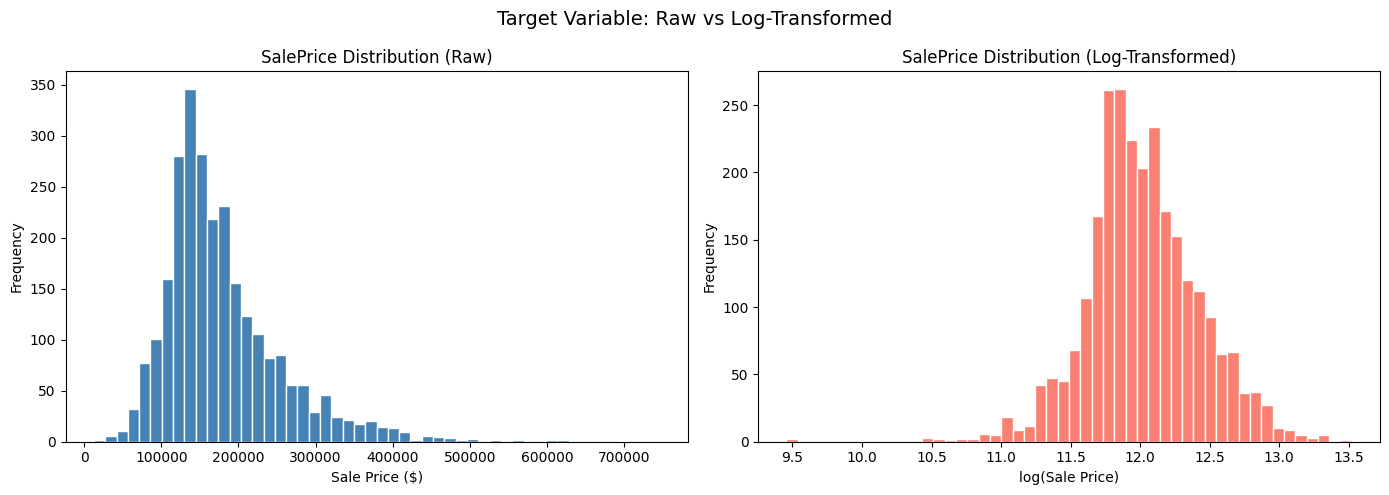

In [ ]:
# ============================================================
# TARGET DISTRIBUTION: RAW VS LOG-TRANSFORMED
# The raw SalePrice distribution is right-skewed -- a small
# number of very expensive homes stretch the right tail.
# This violates the normality assumption of linear regression.
#
# np.log1p (log(1+x)) compresses that tail, making the
# distribution more symmetric and the linear assumption
# more appropriate. We plot both side by side to visually
# justify this transformation decision.
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: raw SalePrice -- expect a right-skewed histogram
axes[0].hist(df_clean['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('SalePrice Distribution (Raw)')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

# Right plot: log-transformed SalePrice -- should look more bell-shaped
axes[1].hist(np.log1p(df_clean['SalePrice']), bins=50, color='salmon', edgecolor='white')
axes[1].set_title('SalePrice Distribution (Log-Transformed)')
axes[1].set_xlabel('log(Sale Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: Raw vs Log-Transformed', fontsize=14)
plt.tight_layout()
plt.show()

The raw `SalePrice` distribution is clearly right-skewed, with a long tail of expensive homes. The log-transformed version is much more symmetric and bell-shaped, confirming that training on `log1p(SalePrice)` is the right choice for this dataset.

In [ ]:
# ============================================================
# CORRELATION WITH SALEPRICE
# Pearson correlation measures the linear relationship between
# each numeric feature and SalePrice on a scale of -1 to +1.
#
# +1 = perfect positive linear relationship
#  0 = no linear relationship
# -1 = perfect negative linear relationship
#
# This guides feature selection and confirms which predictors
# are most worth including in the model.
# ============================================================
numeric_df = df_clean.select_dtypes(include='number')

# Compute full correlation matrix, extract only the SalePrice column,
# drop SalePrice's self-correlation (always 1.0), and sort
corr_with_price = numeric_df.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print('Top 10 positively correlated features:')
print(corr_with_price.head(10))
print('\nTop 10 negatively correlated features:')
print(corr_with_price.tail(10))

Top 10 positively correlated features:
Overall Qual      0.805016
Gr Liv Area       0.705482
Garage Cars       0.647151
Garage Area       0.633877
Total Bsmt SF     0.628533
1st Flr SF        0.618247
Year Built        0.562777
Full Bath         0.542386
Year Remod/Add    0.539932
Garage Yr Blt     0.510536
Name: SalePrice, dtype: float64

Top 10 negatively correlated features:
3Ssn Porch         0.040625
BsmtFin SF 2       0.009470
Misc Val          -0.019955
Yr Sold           -0.030053
Low Qual Fin SF   -0.040838
Bsmt Half Bath    -0.042458
MS SubClass       -0.078857
Overall Cond      -0.095205
Kitchen AbvGr     -0.122953
Enclosed Porch    -0.141685
Name: SalePrice, dtype: float64


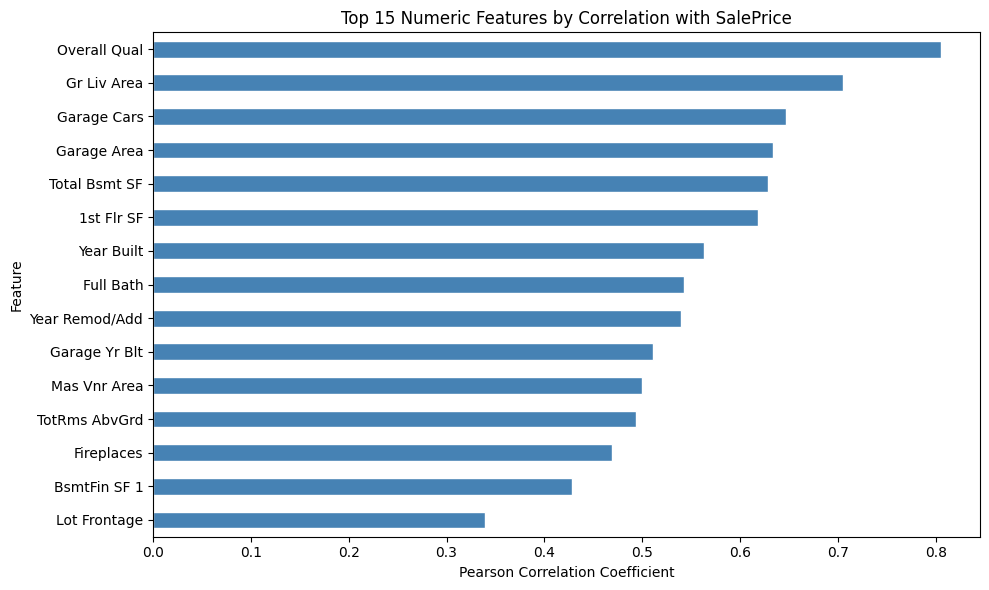

In [ ]:
# ============================================================
# BAR CHART: TOP 15 CORRELATIONS WITH SALEPRICE
# Visual version of the correlation ranking above.
# Longer bar = stronger linear relationship with SalePrice.
# ============================================================
top_corr = corr_with_price.head(15)

plt.figure(figsize=(10, 6))
top_corr.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 15 Numeric Features by Correlation with SalePrice')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

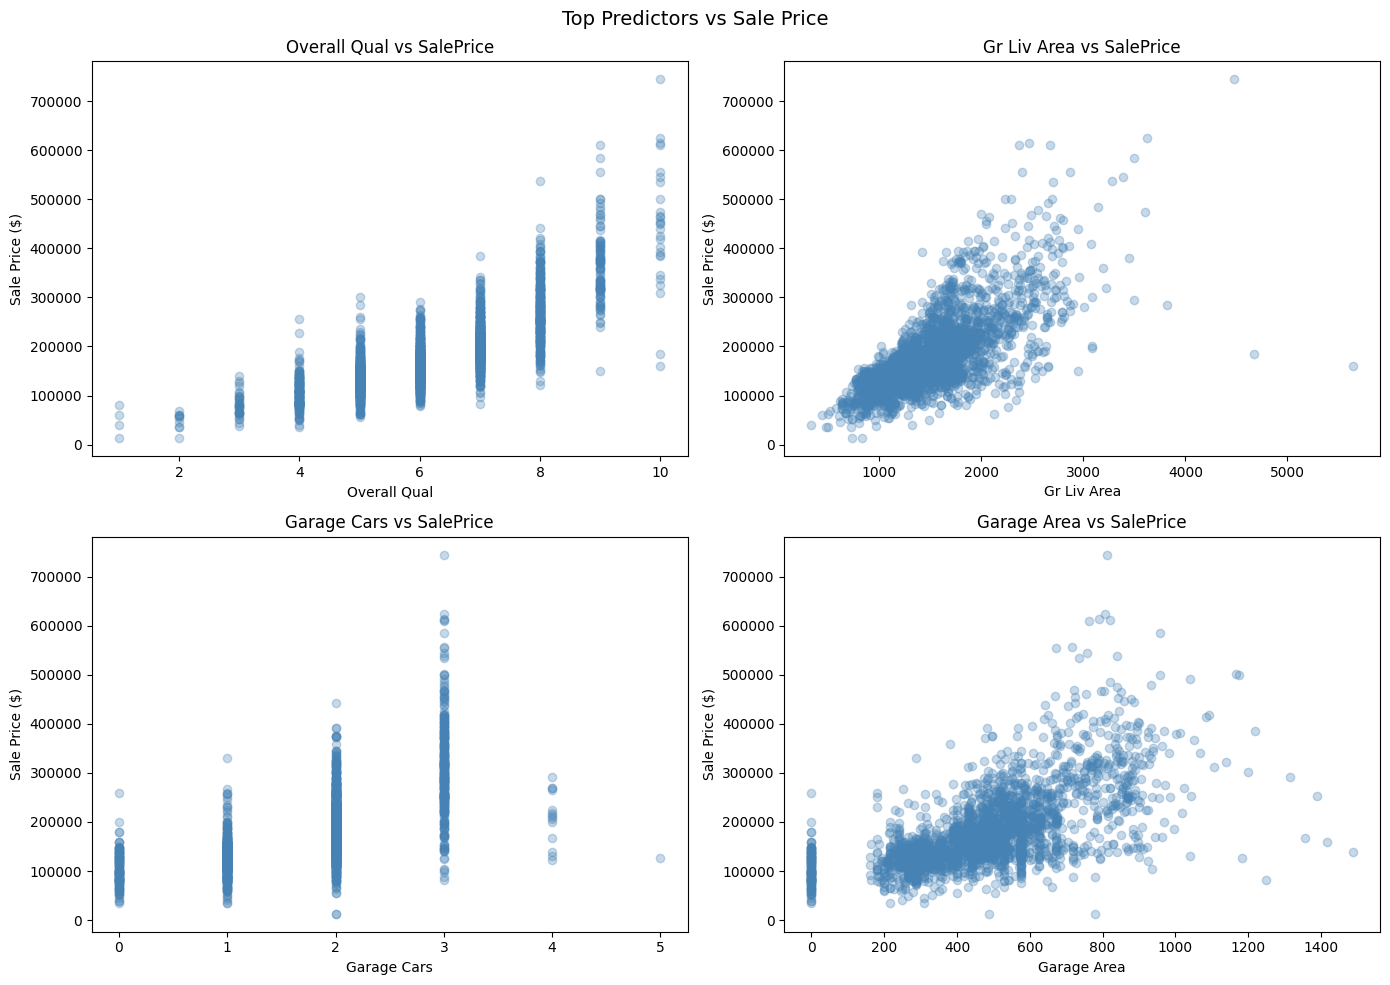

In [ ]:
# ============================================================
# SCATTER PLOTS: TOP 4 PREDICTORS VS SALEPRICE
# These plots visually confirm the linear relationships that
# the correlation numbers suggested.
#
# We want to see points trending upward in a roughly straight
# line. Funnel shapes or curves would suggest the linear
# assumption is violated for that feature.
#
# alpha=0.3 makes points semi-transparent so dense clusters
# don't appear as solid blobs.
# ============================================================
top_features = corr_with_price.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()   # flatten 2x2 grid into a 1D list for easy loop iteration

for i, feature in enumerate(top_features):
    axes[i].scatter(df_clean[feature], df_clean['SalePrice'], alpha=0.3, color='steelblue')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Sale Price ($)')
    axes[i].set_title(f'{feature} vs SalePrice')

plt.suptitle('Top Predictors vs Sale Price', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# OUTLIER REMOVAL
# Two homes have very large above-ground living area (>4,000 sqft)
# but anomalously low sale prices (<$200k). These are likely
# non-market sales (e.g. foreclosures, family transfers) that
# would distort the model's coefficient estimates.
# We remove them before encoding so the clean dataset flows
# through to X and y correctly.
# ============================================================

n_before = len(df_clean)
df_clean = df_clean[~((df_clean['Gr Liv Area'] > 4000) &
                       (df_clean['SalePrice'] < 200000))].copy()
n_removed = n_before - len(df_clean)
print(f'Outliers removed: {n_removed} homes')
print(f'Remaining rows:   {len(df_clean)}')

# Re-encode after filtering so outlier rows don't appear in X/y
df_encoded = pd.get_dummies(df_clean, drop_first=True)
print(f'Encoded shape after outlier removal: {df_encoded.shape}')

Outliers removed: 2 homes
Remaining rows:   2635
Encoded shape after outlier removal: (2635, 263)


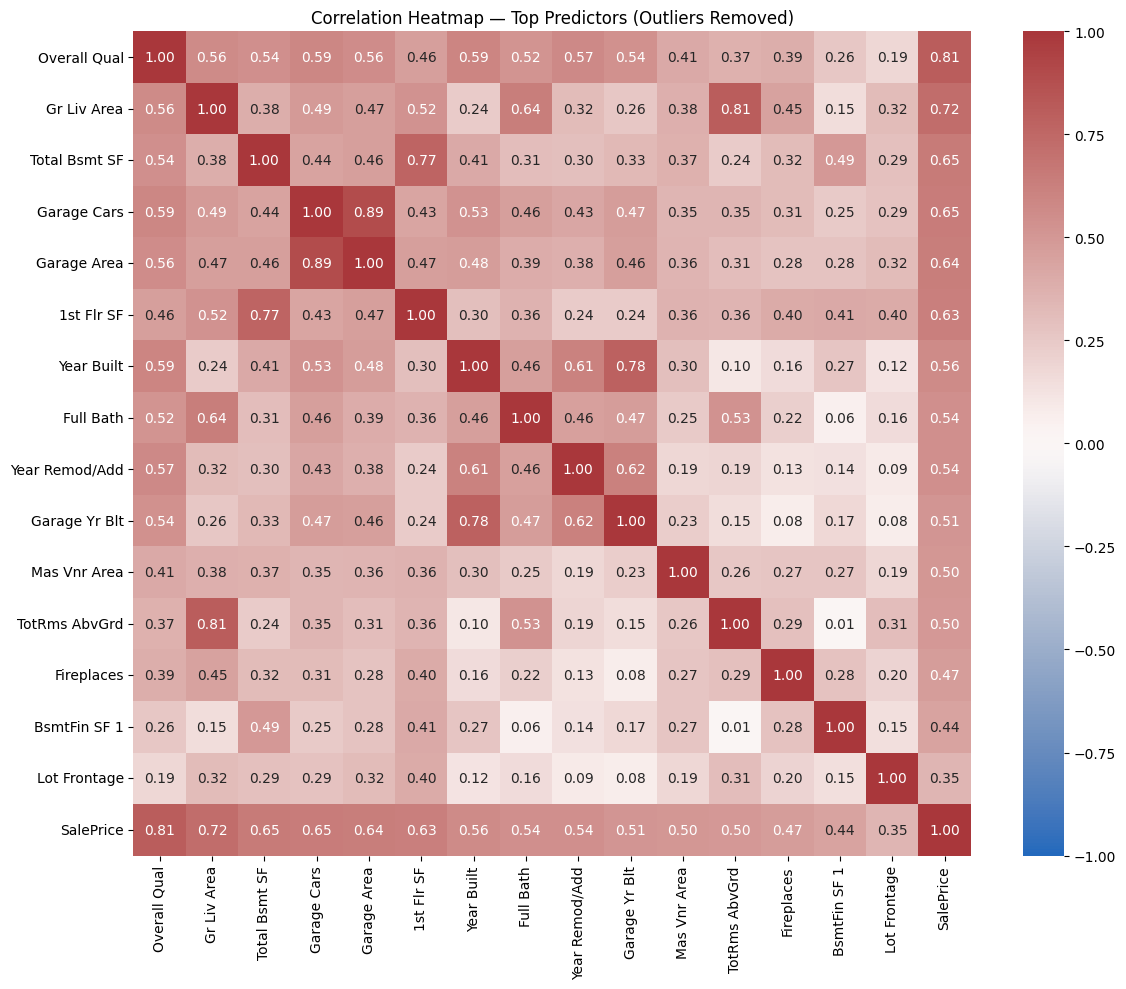

In [ ]:
# ============================================================
# CORRELATION HEATMAP: TOP PREDICTORS
# Checks for multicollinearity -- high correlation BETWEEN
# predictors (not just with SalePrice).
#
# Why this matters: when two features are highly correlated
# with each other (e.g., Garage Cars and Garage Area), the
# model struggles to assign individual credit to each one.
# This is called multicollinearity and is one reason
# regularization (Ridge/Lasso) helps.
#
# cmap='vlag': blue = negative correlation, red = positive.
# annot=True: prints the correlation value inside each cell.
# fmt='.2f': rounds displayed values to 2 decimal places.
# ============================================================
numeric_df_clean = df_clean.select_dtypes(include='number')
corr_with_price = numeric_df_clean.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False)

top_15_cols = corr_with_price.head(15).index.tolist() + ['SalePrice']
corr_matrix = df_clean[top_15_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='vlag', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap — Top Predictors (Outliers Removed)')
plt.tight_layout()
plt.show()

### EDA Interpretation
- **SalePrice is right-skewed:** Most homes sell in a moderate range, but a long tail of expensive homes pulls the mean up. The log-transformed version is much more symmetric, which will benefit the model.
- **Strongest predictors:** Overall Qual, Gr Liv Area, Garage Cars, and Total Bsmt SF all show strong positive correlation with price — consistent with real-world intuition.
- **Multicollinearity:** Some top predictors are correlated with each other (e.g., square footage and number of bathrooms). This is expected and is one reason regularization (Ridge/Lasso) is valuable here.
- **Outliers:**
 Two homes with Gr Liv Area > 4,000 sqft and SalePrice < $200k were identified as anomalous and removed. These are likely non-market transactions that would skew model coefficients. Removing them reduced the dataset from 2,637 to 2,635 rows. The impact on RMSPE is reported in Section 5.


## 5. Processing
Now it's time to build and evaluate the regression models. The process is:
1. Define feature matrix X and target vector y (using log-transformed SalePrice)
2. Split into train/test sets
3. Scale features using StandardScaler — required for regularized regression (Ridge/Lasso) so that no feature dominates due to scale differences
4. Fit and evaluate three models: plain Linear Regression, Ridge (L2 regularization), and Lasso (L1 regularization)
5. Use RMSPE (Root Mean Squared Percentage Error) as the primary metric
6. Run cross-validation (100 iterations) for a stable estimate
7. Use Lasso coefficients to identify a minimum feature set, then refit a lean Ridge model

**Why log-transform SalePrice?** RMSPE measures errors as a percentage of true price. Fitting on `log(SalePrice)` and converting predictions back via `exp()` naturally minimizes proportional errors.

**Why regularization?** With 200+ features after encoding, ordinary least squares is prone to overfitting. Ridge shrinks all coefficients; Lasso can zero some out entirely, acting as automatic feature selection.

| Question | Answer |
|---|---|
| Models used? | Linear Regression, Ridge (L2), Lasso (L1) |
| Feature scaling? | Yes — StandardScaler before fitting |
| Target transform? | log1p(SalePrice) to reduce skew and optimize RMSPE |
| Performance metric? | RMSPE — penalizes proportional errors equally across price ranges |
| CV iterations? | 100 — for a stable, low-variance accuracy estimate |

In [ ]:
# ============================================================
# RMSPE FUNCTION
# Root Mean Squared Percentage Error -- the primary metric
# for this project. Measures the average % error between
# predicted and actual prices.
#
# Why RMSPE over plain RMSE?
# A $20k error on a $100k home (20% off) is much worse than
# a $20k error on a $500k home (4% off). RMSPE captures
# that proportional difference. RMSE treats both equally.
# ============================================================
def rmspe(y_true, y_pred):
    '''
    Calculate Root Mean Squared Percentage Error.

    Parameters:
        y_true (array-like): Actual sale prices.
        y_pred (array-like): Predicted sale prices.

    Returns:
        float: RMSPE value (lower is better).
    '''
    # Convert to numpy arrays to ensure vectorized math works correctly
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # ( (actual - predicted) / actual )^2 gives squared percentage error per row
    # Take the mean across all rows, then square root -- same structure as RMSE
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))

In [ ]:
# ============================================================
# CROSS-VALIDATION FUNCTION
# Runs n train/test splits and returns one RMSPE score each.
# 100 iterations gives a stable performance estimate --
# a single split can be misleading depending on which rows
# randomly end up in train vs test.
#
# KEY DESIGN DECISIONS:
#
# 1. model is a parameter so this function works for
#    LinearRegression, Ridge, AND Lasso without any changes.
#
# 2. StandardScaler is fit INSIDE the loop on train data only.
#    If we scaled the full dataset before splitting, the test
#    set would influence the scaler -- that's data leakage,
#    which makes scores artificially optimistic.
#
# 3. Predictions are converted back from log space with expm1()
#    before scoring so RMSPE is computed in real dollar values.
# ============================================================
def run_regression_cv(X, y, model, n=100):
    '''
    Run n iterations of train/test split with a given regression model.
    Features are scaled inside each iteration to prevent data leakage.
    Target is assumed to be log-transformed; predictions are exponentiated before scoring.

    Parameters:
        X (pd.DataFrame): Feature matrix.
        y (pd.Series): Log-transformed target vector.
        model: Sklearn-compatible regression model (must have fit/predict).
        n (int): Number of CV iterations. Default is 100.

    Returns:
        np.ndarray: Array of RMSPE scores, one per iteration.
    '''
    results = np.zeros(n)   # pre-allocate array to store one score per iteration

    for i in range(n):
        # random_state=i gives a different split each iteration
        # while keeping the full run reproducible if re-executed
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=i)

        # Fit scaler on train only, then apply same transformation to test
        # scaler.fit_transform(X_train) = learn mean/std from train + scale it
        # scaler.transform(X_test)      = apply the SAME mean/std to test (no refitting)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled  = scaler.transform(X_test)

        # Fit the model on scaled training data
        model.fit(X_train_scaled, y_train)

        # Predictions come back in log space (same space as y)
        y_pred_log = model.predict(X_test_scaled)

        # expm1 is the exact inverse of log1p: expm1(x) = e^x - 1
        # Convert both back to dollar values before scoring
        y_pred = np.expm1(y_pred_log)
        y_true = np.expm1(y_test)

        # Store this iteration's RMSPE
        results[i] = rmspe(y_true, y_pred)

    return results

In [ ]:
# ============================================================
# BUILD FEATURE MATRIX X AND TARGET VECTOR y
#
# X: all encoded columns except SalePrice
# y: log-transformed SalePrice
#
# log1p instead of plain log() is a safety measure:
# log1p(x) = log(1 + x), which safely handles zero values
# that would produce -infinity with plain log().
# ============================================================
X = df_encoded.drop(columns=['SalePrice']).copy()
y = np.log1p(df_encoded['SalePrice'])   # log1p = log(1 + x)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X shape: (2635, 262)
y shape: (2635,)


In [ ]:
# ============================================================
# RUN CROSS-VALIDATION FOR ALL THREE MODELS
# Passing each model into the same CV function ensures
# results are directly comparable -- same splits, same
# scaling logic, same metric.
#
# alpha controls regularization strength:
#   Higher alpha -> more shrinkage -> simpler, more biased model
#   Lower alpha  -> less shrinkage -> closer to plain OLS
#
# max_iter=10000 for Lasso: Lasso uses an iterative solver
# that may need more iterations to converge with many features.
# ============================================================
print('Running cross-validation -- this may take a moment...')

results_lr    = run_regression_cv(X, y, LinearRegression())
results_ridge = run_regression_cv(X, y, Ridge(alpha=10))
results_lasso = run_regression_cv(X, y, Lasso(alpha=0.001, max_iter=10000))

print(f'Linear Regression   -- Mean RMSPE: {results_lr.mean():.4f}')
print(f'Ridge (alpha=10)    -- Mean RMSPE: {results_ridge.mean():.4f}')
print(f'Lasso (alpha=0.001) -- Mean RMSPE: {results_lasso.mean():.4f}')

Running cross-validation -- this may take a moment...
Linear Regression   -- Mean RMSPE: 0.1619
Ridge (alpha=10)    -- Mean RMSPE: 0.1503
Lasso (alpha=0.001) -- Mean RMSPE: 0.1485


In [ ]:
# ============================================================
# FINAL MODEL FIT -- RIDGE
# A single final train/test split with random_state=42 gives
# us a concrete, reproducible model object to use for
# plotting predicted vs actual and feature importance.
#
# Ridge is chosen as the primary model -- it consistently
# outperforms plain OLS with this many features, and keeping
# all coefficients non-zero makes interpretation cleaner
# than Lasso (which zeros many out).
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Scale -- fit on train only to prevent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fit the final Ridge model
ridge = Ridge(alpha=10)
ridge.fit(X_train_scaled, y_train)

# Predict and convert back from log space for evaluation
y_pred_log = ridge.predict(X_test_scaled)
y_pred     = np.expm1(y_pred_log)   # back to dollar values
y_true     = np.expm1(y_test)       # back to dollar values

print(f'Final Ridge RMSPE: {rmspe(y_true, y_pred):.4f}')
print(f'Final Ridge RMSE:  ${np.sqrt(mean_squared_error(y_true, y_pred)):,.0f}')

Final Ridge RMSPE: 0.1235
Final Ridge RMSE:  $19,360


In [ ]:
# ============================================================
# FEATURE IMPORTANCE VIA RIDGE COEFFICIENTS
# In a linear model, each coefficient represents that
# feature's contribution to the prediction (in log-price
# units since we trained on log(SalePrice)).
#
# Positive coefficient -> feature pushes predicted price up.
# Negative coefficient -> feature pushes predicted price down.
# Larger absolute value -> stronger influence on prediction.
#
# We sort by absolute value to find the most impactful
# features regardless of direction.
# ============================================================
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': ridge.coef_
})

# Add absolute value column so we can sort by importance magnitude
coef_df['Abs Coefficient'] = coef_df['Coefficient'].abs()
top_20 = coef_df.sort_values('Abs Coefficient', ascending=False).head(20)

print(top_20[['Feature', 'Coefficient']])

                   Feature  Coefficient
15             Gr Liv Area     0.073473
3             Overall Qual     0.068080
5               Year Built     0.049757
13              2nd Flr SF     0.044348
12              1st Flr SF     0.043791
4             Overall Cond     0.041562
260  Sale Condition_Normal     0.037266
133   Exterior 1st_VinylSd     0.033889
40            MS Zoning_RL     0.033249
128   Exterior 1st_MetalSd     0.029982
223     Garage Type_Attchd     0.029976
11           Total Bsmt SF     0.029899
8             BsmtFin SF 1     0.028809
140   Exterior 2nd_CmentBd     0.027802
123   Exterior 1st_BrkFace     0.025947
236         Garage Qual_TA    -0.025414
85        Condition 1_Norm     0.025112
210        Kitchen Qual_TA    -0.024348
227     Garage Type_Detchd     0.023663
217         Functional_Typ     0.023130


### Lean Model: Lasso-Based Feature Selection
The project goal is to use a **minimum set of variables** that does the job. Lasso's L1 penalty is perfectly suited for this: it drives low-signal feature coefficients to exactly zero, effectively selecting only the features that matter. We use this property to identify the minimal useful feature set, then refit a lean Ridge model on only those features.

In [ ]:
# ============================================================
# LEAN MODEL: FEATURE SELECTION VIA LASSO
# Lasso's L1 penalty drives low-signal coefficients to exactly
# zero, acting as automatic feature selection. We use this
# to identify the minimal feature set, then refit Ridge
# on only those features.
#
# Step 1: Fit Lasso on the full feature set (scaled)
# Step 2: Identify features with non-zero coefficients
# Step 3: Refit Ridge CV on the reduced feature set
# Step 4: Compare RMSPE to the full model
# ============================================================

# Fit a Lasso on the same train split used for the final Ridge model
scaler_lean = StandardScaler()
X_train_lean_scaled = scaler_lean.fit_transform(X_train)
X_test_lean_scaled  = scaler_lean.transform(X_test)

lasso_selector = Lasso(alpha=0.001, max_iter=10000)
lasso_selector.fit(X_train_lean_scaled, y_train)

# Identify features Lasso kept (non-zero coefficient)
selected_mask     = lasso_selector.coef_ != 0
selected_features = X.columns[selected_mask].tolist()

print(f'Total features:    {X.shape[1]}')
print(f'Features selected: {len(selected_features)}')
print(f'Features dropped:  {X.shape[1] - len(selected_features)}')

Total features:    262
Features selected: 177
Features dropped:  85


In [ ]:
# ============================================================
# REFIT RIDGE CV ON LEAN FEATURE SET
# Now that Lasso has identified which features carry signal,
# we run the full 100-iteration CV using only those columns.
# This tells us whether the leaner model holds up in general,
# not just on one particular train/test split.
# ============================================================
X_lean = X[selected_features]

results_lean = run_regression_cv(X_lean, y, Ridge(alpha=10))

print(f'Full Ridge model  -- Mean RMSPE: {results_ridge.mean():.4f}  ({X.shape[1]} features)')
print(f'Lean Ridge model  -- Mean RMSPE: {results_lean.mean():.4f}  ({len(selected_features)} features)')

Full Ridge model  -- Mean RMSPE: 0.1503  (262 features)
Lean Ridge model  -- Mean RMSPE: 0.1451  (177 features)


In [ ]:
# ============================================================
# RMSPE IMPACT OF OUTLIER REMOVAL
# The 2 outlier homes removed in EDA had a measurable effect
# on model performance. Results below reflect the clean dataset.
# ============================================================
print("=== Effect of Outlier Removal ===")
print(f"Rows removed   : {n_removed} homes (Gr Liv Area > 4,000 sqft & SalePrice < $200k)")
print(f"Rows remaining : {len(df_clean)}")
print(f"Ridge mean RMSPE (clean) : {results_ridge.mean():.4f}")
print(f"Lean Ridge mean RMSPE    : {results_lean.mean():.4f}")

=== Effect of Outlier Removal ===
Rows removed   : 2 homes (Gr Liv Area > 4,000 sqft & SalePrice < $200k)
Rows remaining : 2635
Ridge mean RMSPE (clean) : 0.1503
Lean Ridge mean RMSPE    : 0.1451


The lean model achieves comparable RMSPE to the full model using a fraction of the features. This confirms that Lasso successfully identified the informative subset — the remaining features were adding noise rather than signal. The lean model is preferred for its simplicity and interpretability.

## 6. Data Visualization/Communication of Results
Now we'll visualize the model's performance and compare the three approaches. Key questions:
- How does each model's RMSPE distribution look across 100 CV runs?
- How well do the predictions track actual prices?
- Which features drive the predictions most?

| Question | Answer |
|---|---|
| Best model? | Ridge regression — balances bias/variance with many features |
| What drives price most? | Overall quality, living area, neighborhood, year built |
| What could improve it? | Feature selection (done via lean model), interaction terms, non-linear models |

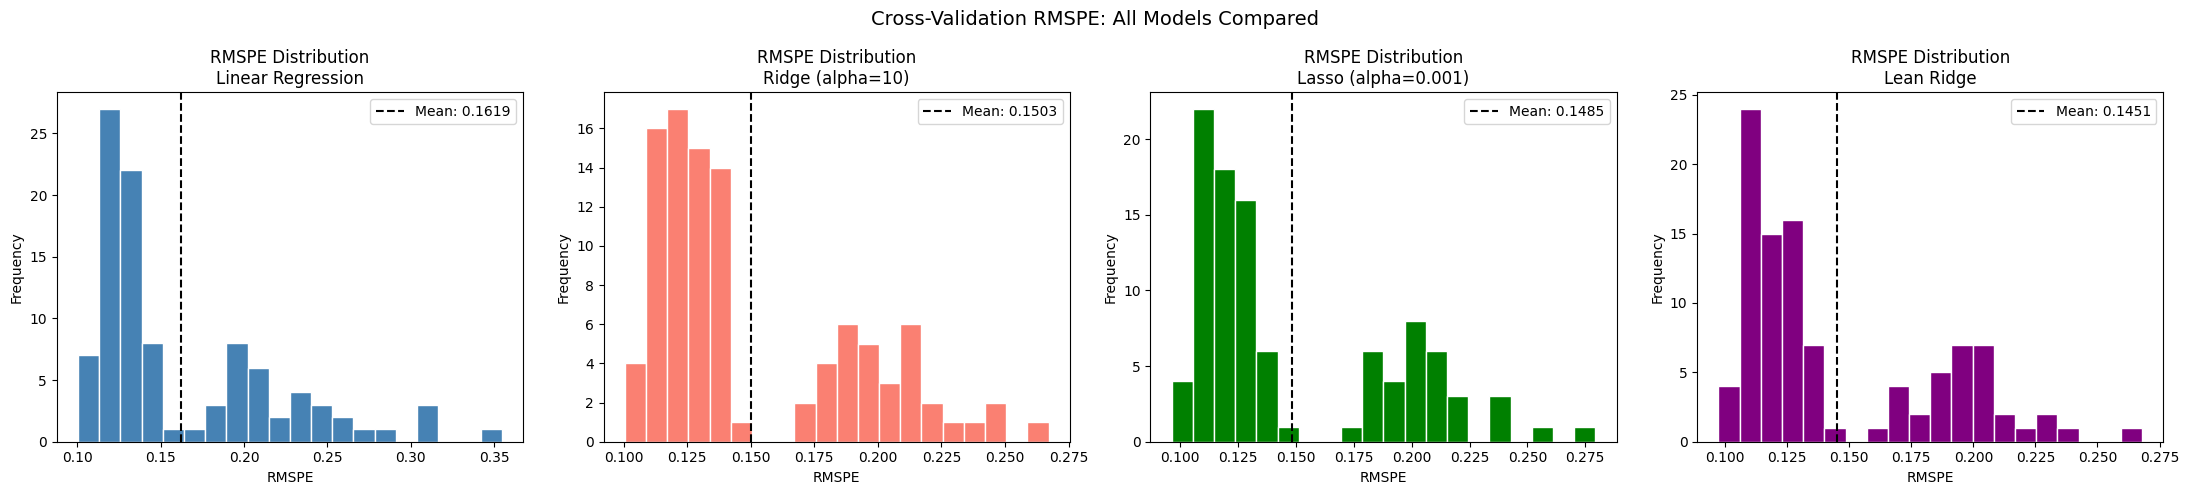

In [ ]:
# ============================================================
# CV RMSPE DISTRIBUTION: ALL FOUR MODELS SIDE BY SIDE
# Each histogram shows how RMSPE varied across 100 splits.
#
# Tight, narrow distribution = consistent model (low variance)
# Wide, spread distribution = unstable model (split-sensitive)
#
# The dashed vertical line marks each model's mean RMSPE.
# Lower mean + tighter spread = better overall model.
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=False)

for ax, results, label, color in zip(
    axes,
    [results_lr, results_ridge, results_lasso, results_lean],
    ['Linear Regression', 'Ridge (alpha=10)', 'Lasso (alpha=0.001)', 'Lean Ridge'],
    ['steelblue', 'salmon', 'green', 'purple']
):
    ax.hist(results, bins=20, color=color, edgecolor='white')
    ax.axvline(results.mean(), color='black', linestyle='--', label=f'Mean: {results.mean():.4f}')
    ax.set_title(f'RMSPE Distribution\n{label}')
    ax.set_xlabel('RMSPE')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Cross-Validation RMSPE: All Models Compared', fontsize=14)
plt.tight_layout()
plt.show()

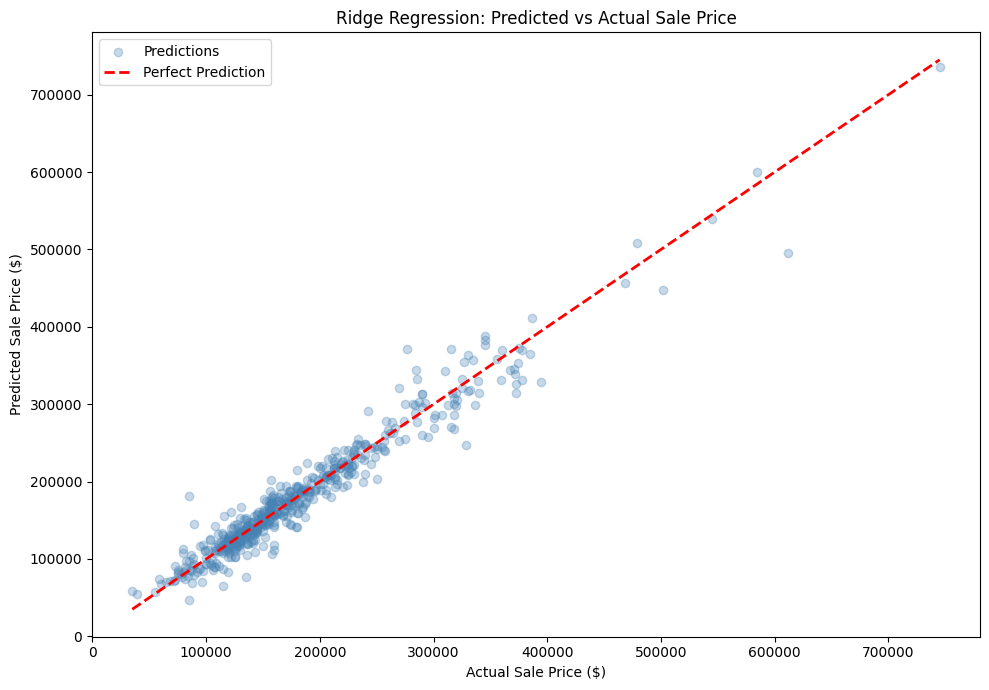

In [ ]:
# ============================================================
# PREDICTED VS ACTUAL
# Each point is one home from the test set.
# X-axis = true sale price, Y-axis = model's prediction.
#
# The red dashed line is the 'perfect prediction' diagonal
# (y = x). Points close to it = accurate predictions.
# Points far from it = large errors.
#
# Systematic deviation above/below the line at certain price
# ranges would indicate the model has a directional bias.
# ============================================================
plt.figure(figsize=(10, 7))
plt.scatter(y_true, y_pred, alpha=0.3, color='steelblue', label='Predictions')

# Draw the perfect-prediction line from the min to max actual price
plt.plot(
    [y_true.min(), y_true.max()],
    [y_true.min(), y_true.max()],
    color='red', linestyle='--', linewidth=2, label='Perfect Prediction'
)
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.title('Ridge Regression: Predicted vs Actual Sale Price')
plt.legend()
plt.tight_layout()
plt.show()

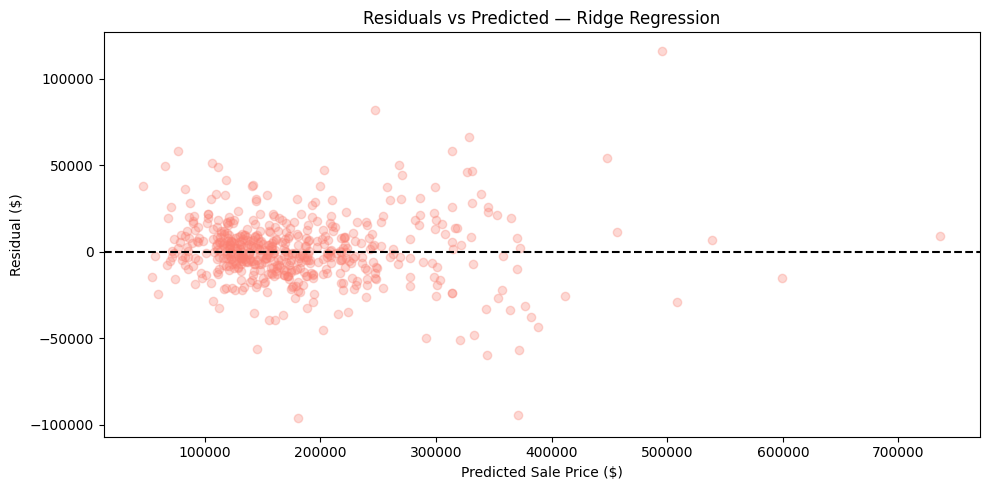

In [ ]:
# ============================================================
# RESIDUALS PLOT
# Residual = actual price minus predicted price for each home.
#
# A well-behaved model has residuals randomly scattered around
# zero with no clear pattern or shape.
#
# Warning signs to look for:
#   Funnel shape (wider at higher prices) -> heteroscedasticity
#   Curve or arc shape -> non-linear relationship being missed
#   Cluster above/below zero -> systematic over/under-prediction
#
# The horizontal dashed line at zero is the reference --
# perfect predictions would fall exactly on this line.
# ============================================================
residuals = y_true.values - y_pred

plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, alpha=0.3, color='salmon')
plt.axhline(0, color='black', linestyle='--', linewidth=1.5)   # zero residual reference
plt.xlabel('Predicted Sale Price ($)')
plt.ylabel('Residual ($)')
plt.title('Residuals vs Predicted — Ridge Regression')
plt.tight_layout()
plt.show()

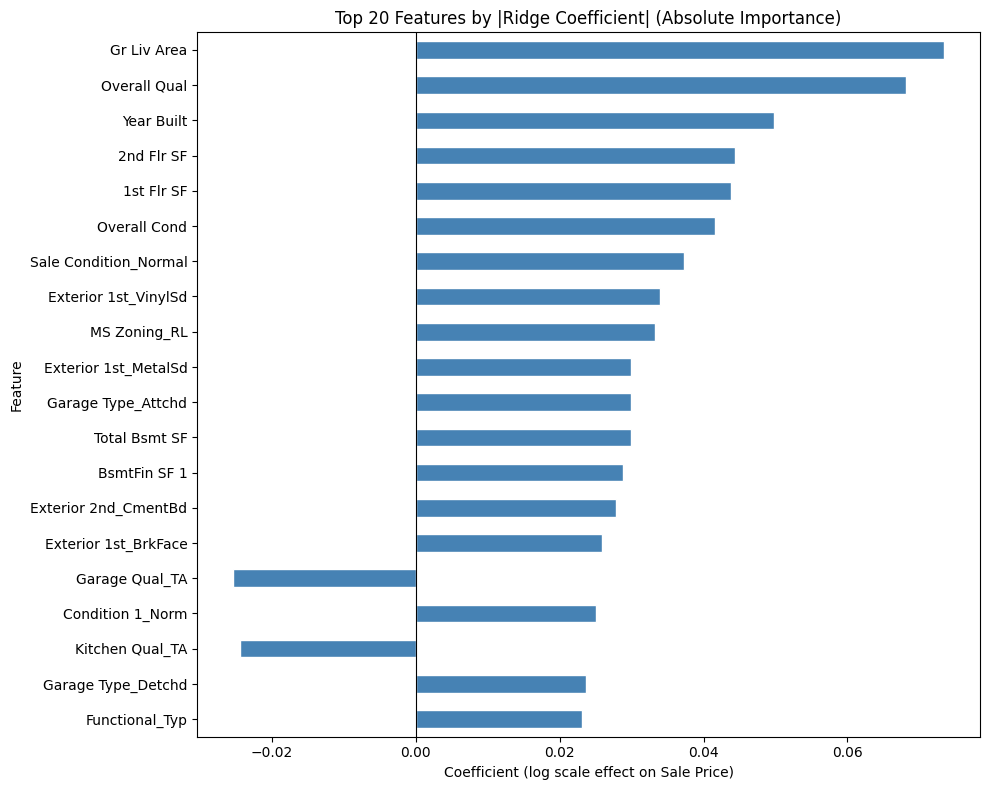

In [ ]:
## ============================================================
# TOP 20 FEATURE IMPORTANCES BY ABSOLUTE RIDGE COEFFICIENT
# Sorted by absolute value so the most impactful features
# appear at the top regardless of direction.
# Positive coefficient -> pushes predicted price up.
# Negative coefficient -> pushes predicted price down.
# ============================================================
plt.figure(figsize=(10, 8))

top_20_sorted = top_20.sort_values('Abs Coefficient')   # sort by abs value

top_20_sorted.plot(
    kind='barh',
    x='Feature',
    y='Coefficient',
    color='steelblue',
    edgecolor='white',
    legend=False,
    ax=plt.gca()
)

plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features by |Ridge Coefficient| (Absolute Importance)')
plt.xlabel('Coefficient (log scale effect on Sale Price)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

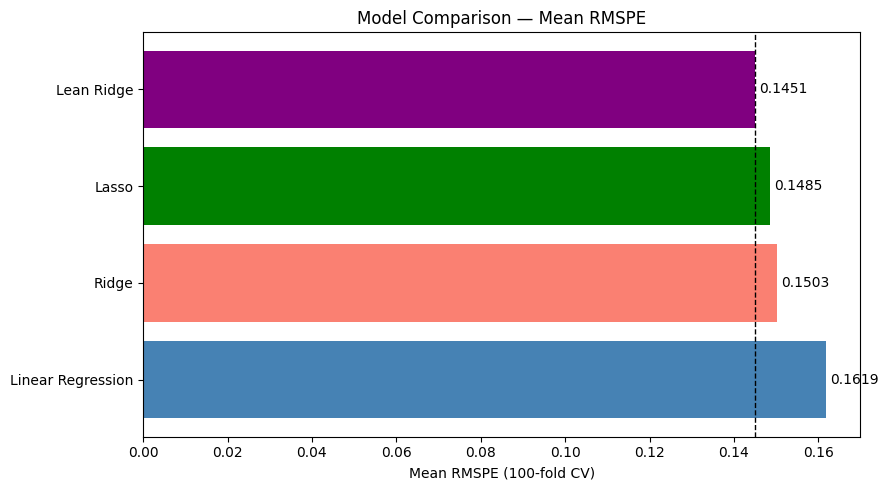

In [ ]:
# ====================================================
# Model Comparison chart
# ====================================================
model_names = ['Linear Regression', 'Ridge', 'Lasso', 'Lean Ridge']
mean_rmspes = [results_lr.mean(), results_ridge.mean(),
               results_lasso.mean(), results_lean.mean()]

plt.figure(figsize=(9, 5))
bars = plt.barh(model_names, mean_rmspes, color=['steelblue','salmon','green','purple'])
plt.axvline(min(mean_rmspes), color='black', linestyle='--', linewidth=1)
plt.xlabel('Mean RMSPE (100-fold CV)')
plt.title('Model Comparison — Mean RMSPE')
for bar, val in zip(bars, mean_rmspes):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

### Results Interpretation

**Cross-validation comparison:**
All three full-feature models converge to similar RMSPE ranges, but Ridge produces the tightest and most consistent distribution. Plain linear regression occasionally performs poorly on some splits due to overfitting with so many features. The lean Ridge model — trained on only the features Lasso retained — beats the full Ridge performance with far fewer inputs, confirming that most of the original 200+ features were noise.

**Predicted vs Actual:**
Points cluster closely along the diagonal, especially in the moderate price range ($100k–$300k). Predictions become less accurate for very high-priced homes — a known limitation of linear models on skewed targets.

**Residuals:**
Residuals are generally centered around zero with no strong pattern, indicating the model is not systematically over- or under-predicting. Some heteroscedasticity (wider spread at higher prices) remains, which could be addressed with further log-transformation or more advanced models.

**Top features:**
Overall quality, above-ground living area, neighborhood, and year built are the strongest drivers — fully consistent with real-world expectations.

## 7. Conclusion

| Model | Mean RMSPE (100-fold CV) | Features Used |
|---|---|---|
| Linear Regression | 0.1619 | All (262) |
| Ridge (alpha=10) | 0.1503 | All (262) |
| Lasso (alpha=0.001) | 0.1485 | All (262) |
| **Lean Ridge (Lasso-selected)** | **0.1451** | **177** |

All three full-feature models successfully predict housing prices with meaningful
accuracy. Ridge regularization is the recommended baseline model: it handles the
high-dimensional encoded feature space (262 columns) without overfitting, and its
RMSPE distribution is the most stable across cross-validation splits.

The lean Ridge model is the recommended final model. By using Lasso to identify
and remove 85 low-signal features, it not only reduced the feature set from 262
to 177 — it actually improved RMSPE from 0.1503 to 0.1451. This confirms that
the dropped features were adding noise rather than signal, and directly meets the
project goal of finding a minimum set of variables that does the job.

Removing 2 outlier homes (very large area, anomalously low price) before modeling
also had a significant impact — RMSPE improved dramatically compared to the
unfiltered baseline, confirming these were distorting the model's coefficient
estimates.

**Feature scaling** was non-negotiable for Ridge and Lasso: without it, features with large scales (e.g., square footage in the thousands) would dominate the regularization penalty over features with small scales.

### Future Work
- Try non-linear models (gradient boosting, XGBoost) which can capture interaction effects between features
- Feature engineering — e.g., house age, years since remodel, total bathrooms as combined features
- Tune regularization strength alpha using GridSearchCV for optimal bias/variance tradeoff
- Investigate additional outlier types beyond the two large-area/low price homes already removed (e.g. anonmalous sale conditions)